In [4]:
df = pd.read_csv(r'C:\Users\Asus\Downloads\Dataset_Predict The Fare Amount Of Future Rides Using Regression Analysis\uber.csv')

In [ ]:
print(df.head())

In [ ]:
print(df.info())

In [21]:
# Dropping columns that aren't useful for analysis
df.drop(columns=['Unnamed: 0', 'key'], inplace=True)

In [ ]:
# Checking for nulls
print(df.isnull().sum())

# Dropping rows with missing values
df.dropna(inplace=True)

In [23]:
# Convert pickup_datetime to datetime objects
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [24]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

#we can now drop the original datetime column
df.drop(columns=['pickup_datetime'], inplace=True)

In [25]:
#removing fares less than or equal to 0
df = df[df['fare_amount'] > 0]

# Remove unrealistic coordinates (New York is roughly -74 long, 40 lat)
df = df[(df['pickup_longitude'] > -80) & (df['pickup_longitude'] < -70)]
df = df[(df['pickup_latitude'] > 35) & (df['pickup_latitude'] < 45)]
df = df[(df['dropoff_longitude'] > -80) & (df['dropoff_longitude'] < -70)]
df = df[(df['dropoff_latitude'] > 35) & (df['dropoff_latitude'] < 45)]

print(f"Cleaned dataset size: {df.shape}")

Cleaned dataset size: (195100, 12)


In [26]:
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    #radius of the Earth in kilometers
    r = 6371 
    
    #converting degrees to radians
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    # Haversine formula
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return r * c

In [27]:
df['dist_travel_km'] = haversine_distance(
    df['pickup_latitude'], 
    df['pickup_longitude'], 
    df['dropoff_latitude'], 
    df['dropoff_longitude']
)

#viewing the new column alongside the fare
print(df[['fare_amount', 'dist_travel_km']].head())

   fare_amount  dist_travel_km
0          7.5        1.683323
1          7.7        2.457590
2         12.9        5.036377
3          5.3        1.661683
4         16.0        4.475450


In [28]:
#remove trips with 0 distance (likely cancelled or GPS errors)
df = df[df['dist_travel_km'] > 0]

# Check the maximum distance to see if there are any unrealistic values
print(f"Maximum distance: {df['dist_travel_km'].max()} km")

Maximum distance: 115.07340970263257 km


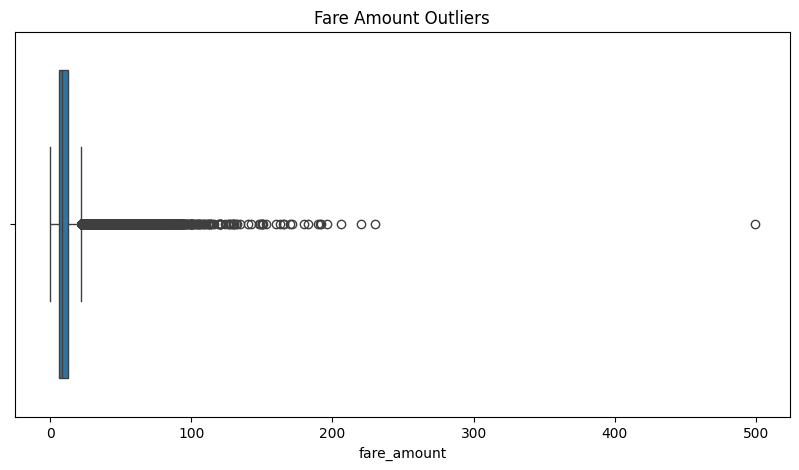

Dataset size after removing fare outliers: (176546, 13)


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing outliers in fare_amount
plt.figure(figsize=(10,5))
sns.boxplot(x=df['fare_amount'])
plt.title("Fare Amount Outliers")
plt.show()

# Removing Outliers using IQR
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['fare_amount'] >= lower_bound) & (df['fare_amount'] <= upper_bound)]
print(f"Dataset size after removing fare outliers: {df.shape}")

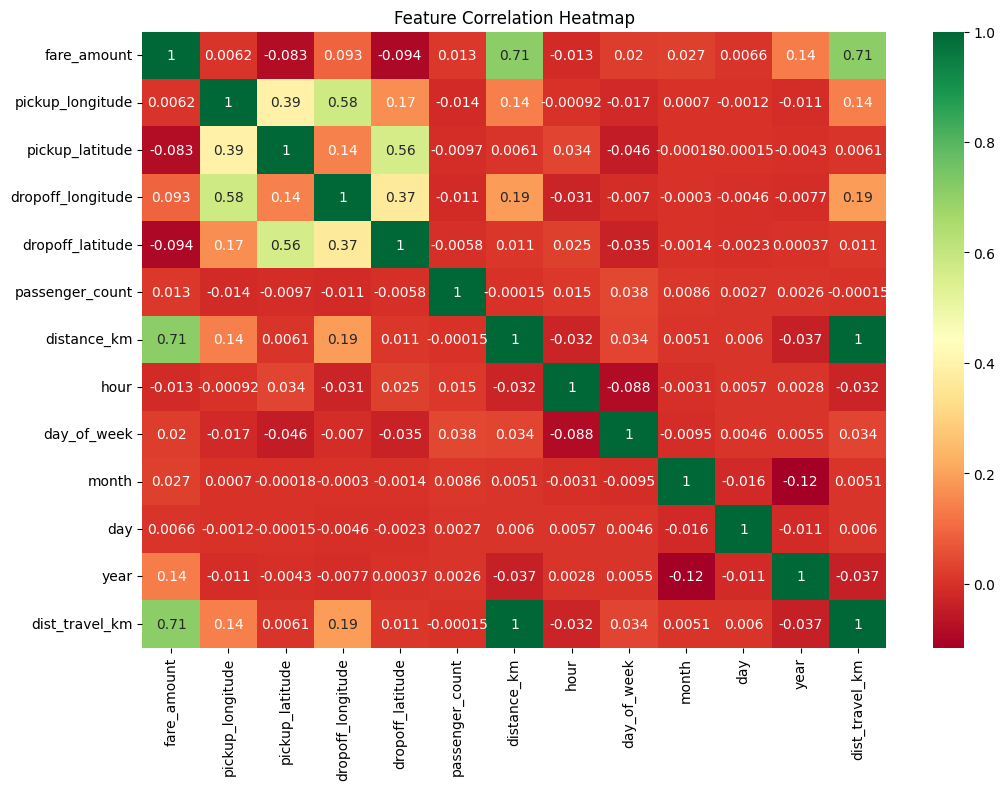

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
!pip install statsmodels

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selecting numerical features for VIF
X_vif = df[['passenger_count', 'hour', 'day', 'month', 'year', 'day_of_week', 'dist_travel_km']]

# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data)

           feature        VIF
0  passenger_count   2.679148
1             hour   5.363317
2              day   4.271131
3            month   4.308610
4             year  17.932240
5      day_of_week   3.502644
6   dist_travel_km   2.476706


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# We scale everything except the target 'fare_amount'
features_to_scale = ['dist_travel_km', 'hour', 'day', 'month', 'year']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Feature Engineering Complete. Data is scaled and ready.")

Feature Engineering Complete. Data is scaled and ready.


In [ ]:
!pip install statsmodels sklearn matplotlib seaborn

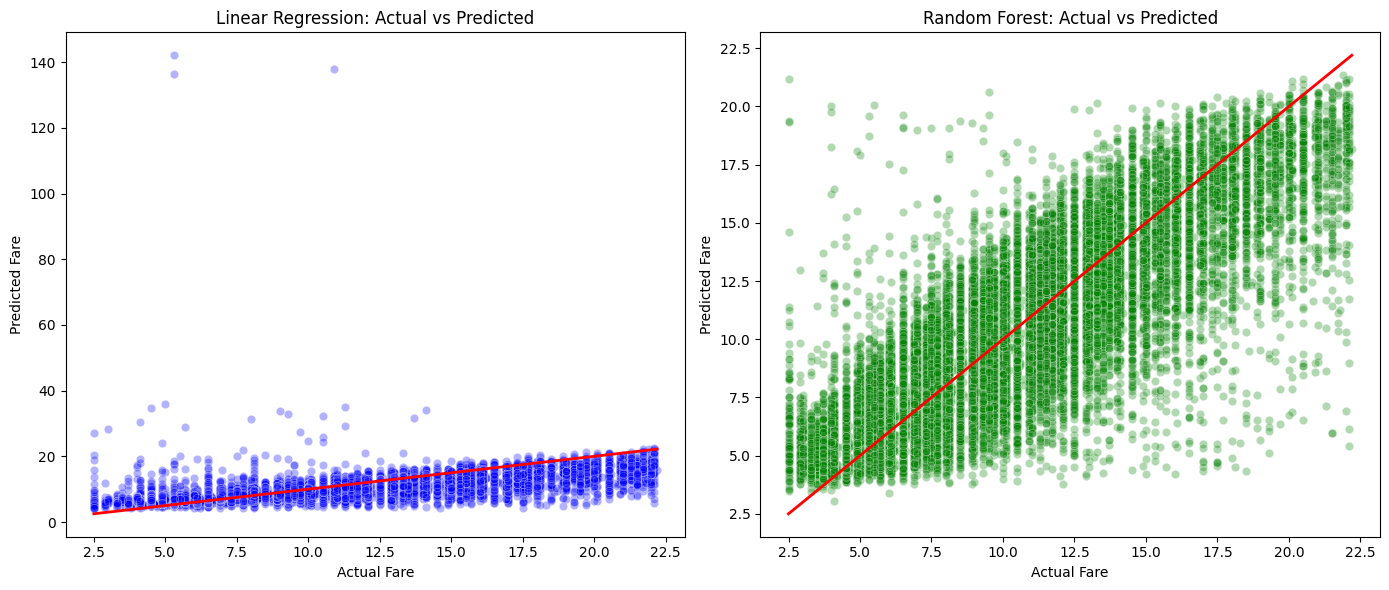

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# --- STEP 1: PREPARE DATA ---
# Ensure you are using the features we engineered (Distance, Year, etc.)
# We drop the target 'fare_amount' from X and assign it to y
X = df[['passenger_count', 'hour', 'day', 'month', 'year', 'day_of_week', 'dist_travel_km']]
y = df['fare_amount']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STEP 2: TRAIN MODELS AND CREATE PREDICTION VARIABLES ---

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)  # This defines y_pred_lr

# 2. Random Forest
# (We use a smaller n_estimators for faster processing)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)  # This defines y_pred_rf


# --- STEP 3: VISUALIZATION (Your Code) ---

plt.figure(figsize=(14, 6))

# Subplot 1: Linear Regression
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.3, color='blue')
# The red line represents a perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')

# Subplot 2: Random Forest
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')

plt.tight_layout()
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_25344\3428225634.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


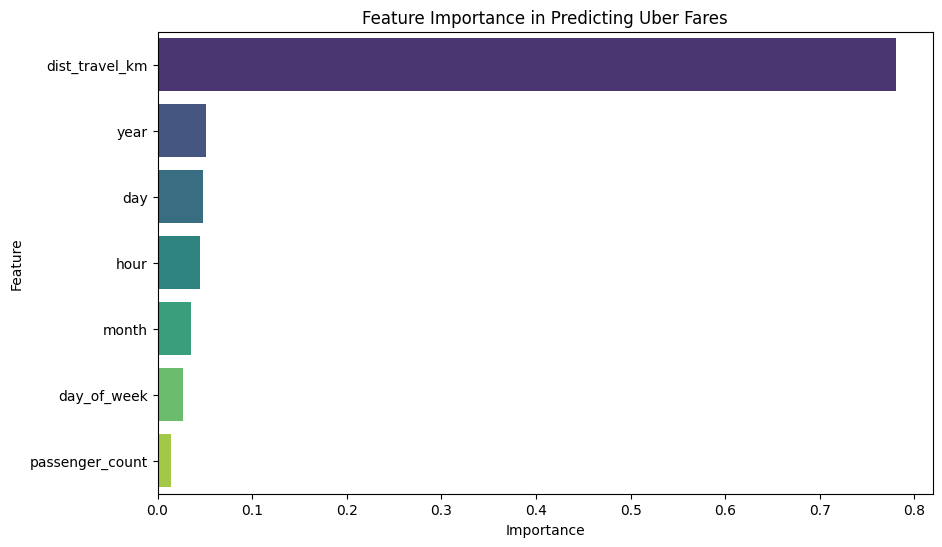

In [42]:
# Getting feature importance from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plotting Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance in Predicting Uber Fares')
plt.show()

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to print all metrics at once
def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {name} Performance ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared Score: {r2:.4f}\n")

# Run the evaluation
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

--- Linear Regression Performance ---
Mean Absolute Error (MAE): 1.83
Mean Squared Error (MSE): 7.55
Root Mean Squared Error (RMSE): 2.75
R-squared Score: 0.5610

--- Random Forest Performance ---
Mean Absolute Error (MAE): 1.50
Mean Squared Error (MSE): 4.42
Root Mean Squared Error (RMSE): 2.10
R-squared Score: 0.7432



C:\Users\Asus\AppData\Local\Temp\ipykernel_25344\1476825034.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=error_df, palette='magma')


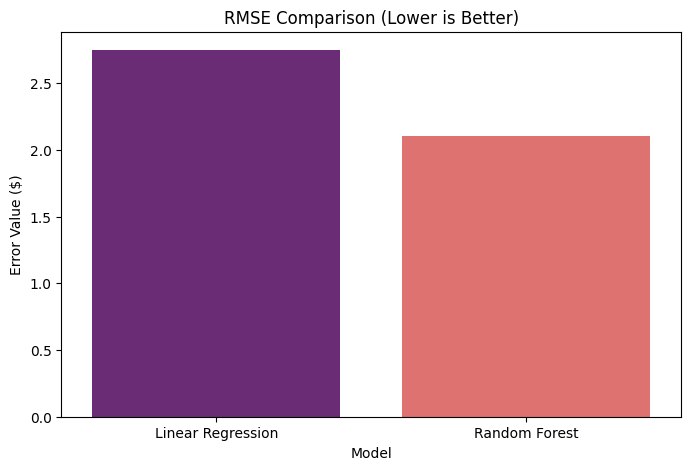

In [44]:
metrics = {
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)), 
             np.sqrt(mean_squared_error(y_test, y_pred_rf))]
}

import pandas as pd
error_df = pd.DataFrame(metrics)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='RMSE', data=error_df, palette='magma')
plt.title('RMSE Comparison (Lower is Better)')
plt.ylabel('Error Value ($)')
plt.show()

In [45]:
from sklearn.model_selection import RandomizedSearchCV

# Define the grid of hyperparameters to search
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize the Random Forest
rf = RandomForestRegressor(random_state=42)

# Initialize RandomizedSearchCV
# n_iter=5 means it will try 5 random combinations from the grid
# cv=3 means it uses 3-fold cross-validation
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                               n_iter=5, cv=3, verbose=2, random_state=42, n_jobs=-1)

In [ ]:
# Train the tuned model
rf_random.fit(X_train, y_train)

# Get the best parameters found
print("Best Parameters:", rf_random.best_params_)

In [49]:
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Ensure the random search is actually executed
# Note: This might take 1-2 minutes depending on your computer speed
print("Tuning the model... please wait.")
rf_random.fit(X_train, y_train)

# 2. Extract the best model
if hasattr(rf_random, 'best_estimator_'):
    best_rf = rf_random.best_estimator_
    
    # 3. Generate predictions using the tuned model
    y_pred_tuned = best_rf.predict(X_test)

    # 4. Check the new RMSE and compare
    # We use y_pred_rf from our previous task to compare
    new_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    old_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

    print("-" * 30)
    print(f"Success! Best Parameters: {rf_random.best_params_}")
    print(f"Old RMSE: {old_rmse:.4f}")
    print(f"New Tuned RMSE: {new_rmse:.4f}")
    print(f"Improvement: {round(old_rmse - new_rmse, 4)} units")
    print("-" * 30)
else:
    print("Error: The model was not fitted correctly. Please check the training step.")

Tuning the model... please wait.
Fitting 3 folds for each of 5 candidates, totalling 15 fits
------------------------------
Success! Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Old RMSE: 2.1020
New Tuned RMSE: 2.0504
Improvement: 0.0515 units
------------------------------
